<a href="https://colab.research.google.com/github/Asmaa-crea/Cybersecurity-Data-Analysis/blob/main/Cyber_Attack_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 1: Generate Synthetic Cybersecurity Dataset

In [ ]:
 import pandas as pd
 import numpy as np
 np.random.seed(42)
 n_rows=100
 data={
     'Timestamp': pd.date_range(start='2026-06-01', periods=n_rows, freq='h'),
    'Source_IP': [f"192.168.1.{np.random.randint(1, 255)}" for _ in range(n_rows)],
    'Protocol': np.random.choice(['TCP', 'UDP', 'ICMP', None], size=n_rows, p=[0.5, 0.3, 0.1, 0.1]),
    'Packet_Size_Bytes': np.random.randint(40, 65535, size=n_rows),
    'Traffic_Type': np.random.choice(['Normal', 'Malicious', 'Suspicious'], size=n_rows, p=[0.6, 0.3, 0.1])
 }
 df =pd.DataFrame(data)
 df.loc[df.sample(5).index,'Packet_Size_Bytes']=np.nan
 df.loc[df.sample(2).index,'Packet_Size_Bytes']=9999999
 df.head()

,Timestamp,Source_IP,Protocol,Packet_Size_Bytes,Traffic_Type
0,2026-06-01 00:00:00,192.168.1.103,UDP,60858.0,Normal
1,2026-06-01 01:00:00,192.168.1.180,None,46757.0,Normal
2,2026-06-01 02:00:00,192.168.1.93,ICMP,54441.0,Malicious
3,2026-06-01 03:00:00,192.168.1.15,UDP,21596.0,Malicious
4,2026-06-01 04:00:00,192.168.1.107,None,50899.0,Normal


# Step 2: Explore Data Quality and Missing Values

In [ ]:
print ("---General Information About the Dataset----")
df.info()

print("\n--- Number of Missing Values per Column ---")
print(df.isnull().sum())

---General Information About the Dataset----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Timestamp          100 non-null    datetime64[ns]
 1   Source_IP          100 non-null    object        
 2   Protocol           91 non-null     object        
 3   Packet_Size_Bytes  95 non-null     float64       
 4   Traffic_Type       100 non-null    object        
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 4.0+ KB

--- Number of Missing Values per Column ---
Timestamp            0
Source_IP            0
Protocol             9
Packet_Size_Bytes    5
Traffic_Type         0
dtype: int64


# Step 3: Handling Missing Values

In [ ]:
# 1. Fill missing values in 'Protocol' with 'Unknown' (Categorical Data)
df['Protocol'] = df['Protocol'].fillna('Unknown')

# 2. Fill missing values in 'Packet_Size_Bytes' with the Median value (Numerical Data)
median_packet_size = df['Packet_Size_Bytes'].median()
df['Packet_Size_Bytes'] = df['Packet_Size_Bytes'].fillna(median_packet_size)

# 3. Check again if there are any missing values left
print("--- Missing Values After Cleaning ---")
print(df.isnull().sum())

--- Missing Values After Cleaning ---
Timestamp            0
Source_IP            0
Protocol             0
Packet_Size_Bytes    0
Traffic_Type         0
dtype: int64


# Step 4: Handling Outliers in Packet Size

In [ ]:
# 1. Identify rows where Packet Size is greater than the maximum theoretical limit (65535 bytes)
print("--- Outliers Found Before Cleaning ---")
outliers = df[df['Packet_Size_Bytes'] > 65535]
print(outliers[['Source_IP', 'Packet_Size_Bytes']])

# 2. Replace those outlier values with the median packet size
df.loc[df['Packet_Size_Bytes'] > 65535, 'Packet_Size_Bytes'] = df['Packet_Size_Bytes'].median()

print("\n--- Max Packet Size After Cleaning ---")
print("Maximum packet size is now:", df['Packet_Size_Bytes'].max())

--- Outliers Found Before Cleaning ---
       Source_IP  Packet_Size_Bytes
14  192.168.1.88          9999999.0
37  192.168.1.89          9999999.0

--- Max Packet Size After Cleaning ---
Maximum packet size is now: 63774.0


# Step 5: Extract Cybersecurity Insights (EDA)

In [ ]:
print("--- 1. Distribution of Traffic Types ---")
traffic_counts = df['Traffic_Type'].value_counts()
print(traffic_counts)

print("\n--- 2. Average Packet Size per Traffic Type ---")
avg_packet_per_type = df.groupby('Traffic_Type')['Packet_Size_Bytes'].mean()
print(avg_packet_per_type)

--- 1. Distribution of Traffic Types ---
Traffic_Type
Normal        56
Malicious     34
Suspicious    10
Name: count, dtype: int64

--- 2. Average Packet Size per Traffic Type ---
Traffic_Type
Malicious     32249.647059
Normal        30615.482143
Suspicious    29543.400000
Name: Packet_Size_Bytes, dtype: float64


# Step 6: Visualize the Insights

Text(0, 0.5, 'Average Size (Bytes)')

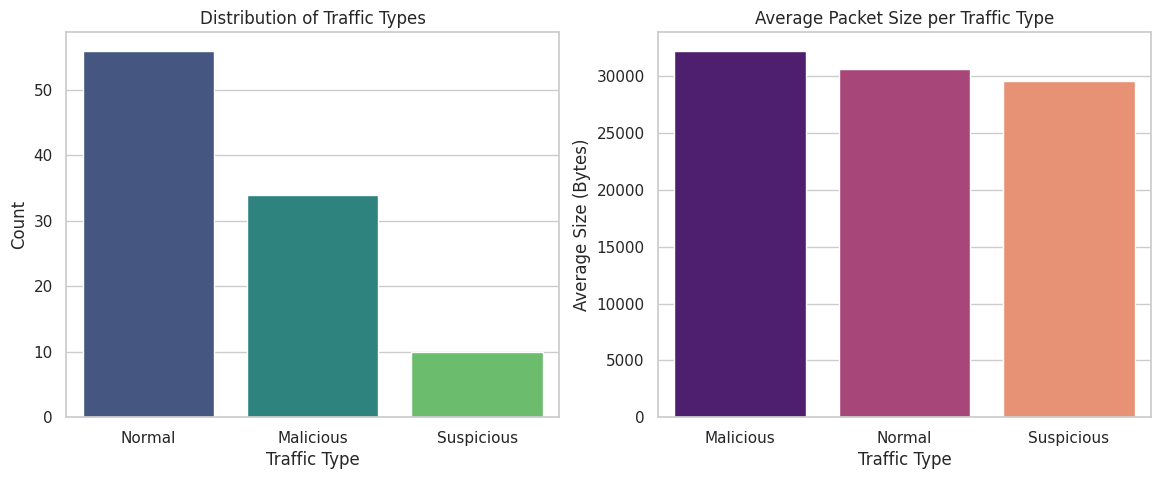

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style of the plots
sns.set_theme(style="whitegrid")

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Count of Traffic Types
sns.countplot(data=df, x='Traffic_Type', ax=axes[0], hue='Traffic_Type', palette='viridis', legend=False)
axes[0].set_title('Distribution of Traffic Types')
axes[0].set_xlabel('Traffic Type')
axes[0].set_ylabel('Count')

# Plot 2: Average Packet Size per Traffic Type
sns.barplot(x=avg_packet_per_type.index, y=avg_packet_per_type.values, ax=axes[1], hue=avg_packet_per_type.index, palette='magma', legend=False)
axes[1].set_title('Average Packet Size per Traffic Type')
axes[1].set_xlabel('Traffic Type')
axes[1].set_ylabel('Average Size (Bytes)')

# Step 7: Feature Encoding using Scikit-learn

In [11]:
from sklearn.preprocessing import LabelEncoder

# 1. Initialize LabelEncoder
le_protocol = LabelEncoder()
le_traffic = LabelEncoder()

# 2. Convert text columns into numbers
df['Protocol_Encoded'] = le_protocol.fit_transform(df['Protocol'])
df['Traffic_Type_Encoded'] = le_traffic.fit_transform(df['Traffic_Type'])

# 3. Display the mapping to see how texts became numbers
print("--- Protocol Mapping ---")
for index, class_name in enumerate(le_protocol.classes_):
    print(f"{class_name} -> {index}")

print("\n--- First 5 rows with Encoded Numbers ---")
df[['Protocol', 'Protocol_Encoded', 'Traffic_Type', 'Traffic_Type_Encoded']].head()

--- Protocol Mapping ---
ICMP -> 0
TCP -> 1
UDP -> 2
Unknown -> 3

--- First 5 rows with Encoded Numbers ---


,Protocol,Protocol_Encoded,Traffic_Type,Traffic_Type_Encoded
0,UDP,2,Normal,1
1,Unknown,3,Normal,1
2,ICMP,0,Malicious,0
3,UDP,2,Malicious,0
4,Unknown,3,Normal,1


# Step 8: Train a Machine Learning Model using Scikit-learn

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Select Features (Inputs) and Target (Output)
X = df[['Protocol_Encoded', 'Packet_Size_Bytes']] # Inputs
y = df['Traffic_Type_Encoded'] # Output (What we want to predict)

# 2. Split data into 80% Training and 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize and Train the Decision Tree Model
ml_model = DecisionTreeClassifier(random_state=42)
ml_model.fit(X_train, y_train)

# 4. Make Predictions and Evaluate
y_pred = ml_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"--- Scikit-learn Model Accuracy: {accuracy * 100:.2f}% ---")
print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred))

--- Scikit-learn Model Accuracy: 50.00% ---

--- Detailed Classification Report ---
              precision    recall  f1-score   support

           0       0.20      0.20      0.20         5
           1       0.62      0.62      0.62        13
           2       0.50      0.50      0.50         2

    accuracy                           0.50        20
   macro avg       0.44      0.44      0.44        20
weighted avg       0.50      0.50      0.50        20



# Step 9: Train a Deep Learning Model using TensorFlow

In [14]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# 1. Convert our training and testing data to float32 (Required by TensorFlow)
X_train_tf = X_train.astype('float32')
X_test_tf = X_test.astype('float32')
y_train_tf = y_train.astype('float32')
y_test_tf = y_test.astype('float32')

# 2. Build the Neural Network Architecture
nn_model = Sequential([
    Dense(16, activation='relu', input_shape=(X_train_tf.shape[1],)), # Hidden Layer 1
    Dense(8, activation='relu'),                                     # Hidden Layer 2
    Dense(3, activation='softmax')                                    # Output Layer (3 classes: Normal, Malicious, Suspicious)
])

# 3. Compile the Model (Set the optimizer and loss function)
nn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Step 10: Train and Evaluate the TensorFlow Neural Network

In [15]:
# 1. Train the model using the training data
print("--- Training TensorFlow Neural Network ---")
history = nn_model.fit(X_train_tf, y_train_tf, epochs=20, batch_size=4, verbose=1)

# 2. Evaluate the model using the test data
loss, tf_accuracy = nn_model.evaluate(X_test_tf, y_test_tf, verbose=0)
print(f"\n--- TensorFlow Model Accuracy: {tf_accuracy * 100:.2f}% ---")

--- Training TensorFlow Neural Network ---
Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.1000 - loss: 7678.3984
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.1000 - loss: 5344.8545
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.1250 - loss: 3359.2168
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.1875 - loss: 2071.8032
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.2000 - loss: 1160.2314
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.2750 - loss: 295.8109
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3500 - loss: 24.9493
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4375 - loss: 29.9988
Epoch 9/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5500 - loss: 24.4272
Epoch 10/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4375 - loss: 25.6576
Epoch 11/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4000 - loss: 27.323